# Entire and modular pipeline

## Steps:
You need to generate the patches first (not done here, see Eric's code)
1. Create deeplake dataset
2. Obtain embeddings (through chosen model, here Gigapath) with storage
3. Linear probing and computations of the performances

TODO: generate a code that connects embeddings and linear probing all at once without storage. 

## 0. Requirements

### Variables

In [1]:
dataset_name = "FDA_CD"
#function to transform the pictures

#input dataset
input_root = "/home/leolr-int/nfs/data/data/patched/dim_256/Train" 
#output dataset if transformation
output_root = f"/home/leolr-int/nfs/transformed_data/{dataset_name}_deeplake/patched/dim_256/Train"


from Fourier_Domain_Adaptation.FDA_CD import FDA_CD
function = FDA_CD


### Packages

In [2]:
import json
import os
import pickle
import platform
import random
import yaml
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor
from datetime import datetime
from functools import partial
from pathlib import Path
from typing import Any, Callable, Dict, Iterable, List, Literal, Optional, Tuple, Union

import deeplake
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyvips
import seaborn as sns
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
from torch.amp import GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms
from tqdm import tqdm
from dotenv import load_dotenv
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, precision_score, recall_score)
from timm.layers import SwiGLUPacked
from timm.models.vision_transformer import VisionTransformer

'''
from requirements_emb import (
    get_args,
    set_seed,
    log_device,
    log_metrics,
    embedding_transform_fn,
    Network,
    NetworkHandler,
    CONFIG_DIR,
    BORDER_WIDTH,
    BASE_MODEL_DIR
)'''

import pynvml

/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [3]:
# ==================
#   PATH CONSTANTS
# ==================

ROOT_DIR = "/home/leolr-int/AGGCPerturbations"
#ROOT_DIR = str(Path(__file__).resolve().parents[2])
SRC_DIR = os.path.join(ROOT_DIR, "src")
ASSET_DIR = os.path.join(ROOT_DIR, "assets")
RESULTS_DIR = os.path.join(ROOT_DIR, "results")
PROFILING_DIR = os.path.join(ROOT_DIR, "profiling")

#DATA_DIR = os.path.join(ROOT_DIR, "data")
#DATA_DIR = '/home/leolr-int/nfs/data/data'
DATA_DIR = f'/home/leolr-int/nfs/transformed_data/{dataset_name}_deeplake'


RAW_DIR = os.path.join(DATA_DIR, "raw")
RUN_DIR = os.path.join(ROOT_DIR, "tensorboard")
SPLIT_DIR = os.path.join(DATA_DIR, "splits")
CONFIG_DIR = os.path.join(ROOT_DIR, "configs")
PATCH_DIR = os.path.join(DATA_DIR, "patched")

METADATA_DIR = '/home/leolr-int/nfs/data/data/metadata'

PATCH_TABLE_DIR = os.path.join(DATA_DIR, "patch_tables")
BASE_MODEL_DIR = os.path.join(ROOT_DIR, "model_weights")
FULL_PATCH_DIR = os.path.join(DATA_DIR, "patched_full") # only used for downstream analysis
HISTOGRAM_DIR = os.path.join(DATA_DIR, "histogram_matching_stats")
COMBINED_PATCH_DIR = os.path.join(DATA_DIR, "patched_combined")

# modify DATADIR above!!!!

#var to be modified
scanner = "KFBio"
EMBEDDING_DIR = f'/home/leolr-int/nfs/transformed_data/new_embeddings/{dataset_name}'

# ===================
#   LABEL CONSTANTS  
# ===================

LABEL_MAP = {
    "Stroma": 0,
    "Normal": 1,
    "G3":     2,
    "G4":     3,
    "G5":     4
}

COLOR_MAP = {
    0: [242, 182, 216],   
    1: [163, 196, 243],  
    2: [255, 213, 128],   
    3: [190, 224, 200],   
    4: [217, 185, 255],   
}

SEVERITY_COLOR_MAP = {
    0: [255, 0,     255],
    1: [51,  0,     255],
    2: [51,  255,   0  ],
    3: [255, 229.5, 0  ],
    4: [255, 0,     0  ]
}

# ===================
#   MODEL CONSTANTS
# ===================

ENCODER_DIMS = {
    "uni":      1024,
    "gigapath": 1536,
    "virchow":  2560
}

PRETRAINED_ENCODERS = {
    "uni", 
    "gigapath", 
    "virchow"
}

# ===================
#   MISC. CONSTANTS  
# ===================

SCANNERS = {"akoya", "kfbio", "leica", "olympus", "philips", "zeiss"}
GRAPH_COLORS = ["#ff66c4", "#cb6ce6", "#875dca"]
BORDER_WIDTH = 70

### Required functions

In [4]:
# ==================
#   get_args
# ==================

def get_args(args_path: str) -> Dict[str, Union[float | str]]:

    """
    Gets relevant arguments from a yaml file.

    Parameters
    ----------
    args_path: str
        The path to the yaml file containing the arguments.
    
    Returns
    -------    
    args: Dict[str, Union[float, str]]
        The arguments in the form of a dictionary.
    """

    with open(args_path, "r") as f:
        args = yaml.safe_load(f)

    return args


# ==================
#   load_json
# ==================

def load_json(json_path: str):

    """
    Loads a json object from a path.
    """
    
    with open(json_path, "r") as f:
        json_object = json.load(f)

    return json_object



# ==================
#   save_table
# ==================


def save_table(
    data_dict: Dict[str, Union[str, np.ndarray]],
    save_dir: str,
    filename: str
    ) -> None:

    """
    Converts a dictionary to a pandas DataFrame for downstream analysis.
    """

    os.makedirs(save_dir, exist_ok=True)

    df = pd.DataFrame(data_dict)
    df.to_parquet(os.path.join(save_dir, f"{filename}.parquet"), index=False)


# ==================
#   log_device
# ==================


def log_device():

    if not torch.cuda.is_available():
        print("CUDA not available — running on CPU.")
        return

    if platform.system() == "Darwin": 
        print("NVML not supported on macOS — skipping device log.")
        return

    try:
        pynvml.nvmlInit()
        device_count = pynvml.nvmlDeviceGetCount()
        border = "=" * BORDER_WIDTH

        print(f"\n{border}")
        print(f"{'Devices':^{BORDER_WIDTH}}")
        print(f"{'-' * BORDER_WIDTH}")

        for i in range(device_count):
            handle = pynvml.nvmlDeviceGetHandleByIndex(i)
            mem = pynvml.nvmlDeviceGetMemoryInfo(handle)
            name = pynvml.nvmlDeviceGetName(handle)

            print("\n" + f"{f'GPU {i}: {name}':^{BORDER_WIDTH}}")
            print(f"{f'Memory Used : {mem.used / 1024**2:.2f} MB':^{BORDER_WIDTH}}")
            print(f"{f'Memory Total: {mem.total / 1024**2:.2f} MB':^{BORDER_WIDTH}}\n")

        print(f"{'-' * BORDER_WIDTH}")
        print(f"{f'PyTorch CUDA Available: {torch.cuda.is_available()}':^{BORDER_WIDTH}}")
        print(f"{border}\n")

    finally:
        pynvml.nvmlShutdown()



# ==================
#   Network
# ==================

class Network(nn.Module):

    """
    Initializes the network with a foundation model as the encoder
    and a linear layer as the classifier.

    Parameters
    ----------
    encoder_name: str
        The foundation model to be used as the encoder.
        One of [uni, gigapath, virchow].

    encoder_dir: str
        The directory containing the encoder weights.

    num_classes: int
        The number of classes to be classified.
    
    freeze_encoder: bool
        Whether to freeze the encoder during finetuning.
    """

    def __init__(
        self,
        encoder_name: str,
        encoder_dir: str,
        num_classes: int = 2,
        freeze_encoder: bool = True
        ):
        super().__init__()

        self.encoder = get_encoder(encoder_name, encoder_dir)
        self.fc = get_classification_head(encoder_name, num_classes)
        self.freeze_encoder = freeze_encoder

        if self.freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False

    def forward(self, x):
        if self.freeze_encoder:
            with torch.no_grad():
                embedding = self.encoder(x)

        else:
            embedding = self.encoder(x)
            
        logits = self.fc(embedding)

        return logits


class ClassificationHead(nn.Module):

    """
    Initializes a linear classification head.

    Parameters
    ----------
    in_dim: int
        The input dimension of the classifier.

    out_dim: int
        The output dimension of the classifier or 
        the number of classes.
    """

    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.head = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        logits = self.head(x)

        return logits
    

class VirchowConcat(nn.Module):
    
    """
    Performs the concatenation of the CLS token and mean across patch
    tokens as defined in Virchow.

    Source: https://arxiv.org/pdf/2309.07778

    Parameters
    ----------
    encoder: nn.Module
        The Virchow encoder. 
    """
    
    def __init__(
        self, 
        encoder: nn.Module
        ):
        super().__init__()
        self.encoder = encoder

    def forward(self, x):
        all_tokens = self.encoder(x)

        cls_token = all_tokens[:, 0]
        patch_tokens = all_tokens[:, 1:].mean(1)

        embedding = torch.cat([cls_token, patch_tokens], dim=-1)

        return embedding


def download_weights(
    encoder_name: str,
    encoder_dir: str
    ):

    """
    Downloads the weights of a foundation model to a selected directory.

    Parameters
    ----------
    encoder_name: str
        The foundation model to be used as the encoder.
        One of [uni, gigapath, virchow].

    encoder_dir: str
        The directory containing the encoder weights.
    """

    if encoder_name not in ENCODER_DIMS:
        raise ValueError(f"encoder must be one of {ENCODER_DIMS}")

    if encoder_name == "uni":
        encoder = timm.create_model("hf-hub:MahmoodLab/uni", pretrained=True, init_values=1e-5, dynamic_img_size=True)

    if encoder_name == "gigapath":
        encoder = timm.create_model("hf_hub:prov-gigapath/prov-gigapath", pretrained=True, dynamic_img_size=True)

    if encoder_name == "virchow":
        encoder = timm.create_model("hf-hub:paige-ai/Virchow", pretrained=True, mlp_layer=SwiGLUPacked, act_layer=torch.nn.SiLU)

    encoder_path = os.path.join(encoder_dir, f"{encoder_name}.pth")
    torch.save(encoder, encoder_path)


def get_encoder(
    encoder_name: str,
    encoder_dir: str
    ) -> VisionTransformer:

    """
    Returns an initialized foundation encoder.

    Parameters
    ----------
    encoder_name: str
        The foundation model to be used as the encoder.
        One of [uni, gigapath, virchow].

    encoder_dir: str
        The directory containing the encoder weights.

    Returns
    -------
    encoder: VisionTransformer
        The initialized foundation encoder.
    """

    if encoder_name not in ENCODER_DIMS:
        raise ValueError(f"encoder must be one of {list(ENCODER_DIMS.keys())}.")
    
    os.makedirs(encoder_dir, exist_ok=True)
    encoder_path = os.path.join(encoder_dir, f"{encoder_name}.pth")

    if not os.path.isfile(encoder_path):
        download_weights(encoder_name, encoder_dir=encoder_dir)

    encoder = torch.load(encoder_path, map_location=torch.device("cpu"), weights_only=False)

    if encoder_name == "virchow":
        encoder = VirchowConcat(encoder=encoder)

    return encoder

    
def get_classification_head(
    encoder_name: str,
    num_classes: int
    ) -> ClassificationHead:

    """
    Initializes the appropriate classification head
    according to a selected foundation encoder.

    Parameters
    ----------
    encoder_name: str
        The foundation model to be used as the encoder.
        One of [uni, gigapath, virchow].

    num_classes: int
        The number of output classes.
    """

    if encoder_name not in ENCODER_DIMS:
        raise ValueError(f"encoder must be one of {ENCODER_DIMS}")

    in_dims = ENCODER_DIMS[encoder_name]
    head = ClassificationHead(in_dim=in_dims, out_dim=num_classes)

    return head




# ==================
#   NetworkHandler
# ==================


class NetworkHandler:

    """
    This class encapsulates all computation logic for a given neural network,
    including training, validation, inference and embedding extraction.
    
    Supports mixed precision training.

    Parameters
    ----------
    model: Network
        The neural network.

    criterion: nn.Module
        The function for loss computation.

    optimizer: torch.optim.Optimizer
        The optimizer for gradient descent.

    precision: Literal['single', 'mixed']
        Whether to train in mixed or single precision.
        Must be one of ['single', 'mixed'].

    freeze_encoder: bool
        Whether the encoder is frozen.
        Will be used as a flag in switching between train and eval modes.

    embedding_mode: bool
        Whether to perform computations on pre-extracted embeddings.
    """

    def __init__(
        self,
        model: Network,
        criterion: nn.Module = None,
        optimizer: torch.optim.Optimizer = None, 
        precision: Literal["single", "mixed"] = "single",
        freeze_encoder: bool = True,
        embedding_mode: bool = False
        ):

        valid_precisions = ["single", "mixed"]

        if precision not in valid_precisions:
            raise ValueError(f"precision must be one of  {valid_precisions}.")

        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.freeze_encoder = freeze_encoder
        
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.use_amp = precision == "mixed" and self.device == "cuda"
        self.grad_scaler = GradScaler(enabled=self.use_amp)
        self.model = self.model.to(self.device)
        self.embedding_mode = embedding_mode

        if self.device != "cuda" and precision == "mixed":
            raise ValueError(f"Mixed precision unavailable with current device: {self.device}. Switch to single precision.\n")


    def train_epoch(self, train_loader: DataLoader) -> Tuple[float, float]:

        """
        Trains the model for 1 epoch.

        Parameters
        ----------
        train_loader: DataLoader
            The data loader for training.

        Returns
        -------
        epoch_loss: float
            The loss for the epoch.

        epoch_balanced_accuracy: float
            The average balanced accuracy for the given epoch.  
        """
        
        metrics = {
            "running_loss": 0,
            "predictions": [],
            "targets": []
        }
        
        self.model.train()
        if self.freeze_encoder or self.embedding_mode: self.model.encoder.eval()

        pbar = tqdm(train_loader, desc="Training in progress")

        for patch, target, *_ in pbar:
            patch = patch.to(self.device)
            target =  target.to(self.device)

            with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=self.use_amp):
                logits = self.model.fc(patch) if self.embedding_mode else self.model(patch) 
                loss = self.criterion(logits, target)

            self.grad_scaler.scale(loss).backward()
            self.grad_scaler.step(self.optimizer)
            self.grad_scaler.update()
            self.optimizer.zero_grad()

            confidence = F.softmax(logits, dim=1)
            pred = torch.argmax(confidence, dim=1)

            metrics["running_loss"] += loss.detach().cpu().item()
            metrics["predictions"].extend(pred.cpu().numpy())
            metrics["targets"].extend(target.cpu().numpy())

            pbar.set_postfix({"step_loss": loss.detach().cpu().item()})

        epoch_loss = metrics["running_loss"] / len(train_loader)
        epoch_balanced_accuracy = balanced_accuracy_score(metrics["targets"], metrics["predictions"])

        return epoch_loss, epoch_balanced_accuracy
    

    @torch.no_grad()
    def validate_epoch(self, val_loader: DataLoader) -> Tuple[float, float]:

        """
        Runs validation for 1 epoch.

        Parameters
        ----------
        val_loader: DataLoader
            The data loader for validation.

        Returns
        -------
        epoch_loss: float
            The loss for the epoch.

        epoch_balanced_accuracy: float
            The average balanced accuracy for the given epoch.  
        """

        metrics = {
            "running_loss": 0,
            "predictions": [],
            "targets": []
        }

        self.model.eval()
        pbar = tqdm(val_loader, desc="Validation in progress")
        for patch, target, *_ in pbar:
            patch = patch.to(self.device)
            target = target.to(self.device)

            with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=self.use_amp):
                logits = self.model.fc(patch) if self.embedding_mode else self.model(patch)
                loss = self.criterion(logits, target)

            confidence = F.softmax(logits, dim=1)
            pred = torch.argmax(confidence, dim=1)

            metrics["running_loss"] += loss.detach().cpu().item()
            metrics["predictions"].extend(pred.cpu().numpy())
            metrics["targets"].extend(target.cpu().numpy())

            pbar.set_postfix({"step_loss": loss.detach().cpu().item()})

        epoch_loss = metrics["running_loss"] / len(val_loader)
        epoch_balanced_accuracy = balanced_accuracy_score(metrics["targets"], metrics["predictions"])

        return epoch_loss, epoch_balanced_accuracy
    
    @torch.no_grad()
    def inference(
        self, 
        inference_loader: DataLoader, 
        save_dir: str = None,
        filename: str = None
        ) -> Tuple[float, float]:

        """
        Performs inference and optionally saves the results as a parquet table
        for downstream analysis.

        Parameters
        ----------
        inference_loader: DataLoader
            The data loader for inference.

        save_dir: str
            The directory to save results.

        filename: str
            The filename to save the results into.

        Returns
        -------
        iteration_loss: float
            The average loss during inference.

        iteration_balanced_accuracy:
            The average balanced accuracy during inference.
        """

        if save_dir and not filename:
            raise ValueError("filename cannot be empty if save dir is specified.")
        
        if filename and not save_dir:
            raise ValueError(f"save_dir must be provided to save results as {filename}")

        metrics = {
            "loss": [],
            "confidence_score": [],
            "prediction": [],
            "target": [],
            "area": [],
            "x": [],
            "y": [],
            "w": [],
            "h": [],
            "img_idx": []
        }

        self.model.eval()
        pbar = tqdm(inference_loader, desc="Inference in progress")
        for patch, target, metadata in pbar:
            patch = patch.to(self.device)
            target = target.to(self.device)

            with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=self.use_amp):
                logits = self.model.fc(patch) if self.embedding_mode else self.model(patch)
                loss = self.criterion(logits, target)

            confidence = F.softmax(logits, dim=1)
            pred = torch.argmax(confidence, dim=1)

            metrics["loss"].extend(loss.detach().cpu().numpy())
            metrics["confidence_score"].extend(confidence.cpu().numpy())
            metrics["prediction"].extend(pred.cpu().numpy())
            metrics["target"].extend(target.cpu().numpy())
            
            metrics["area"].extend(metadata["area"].cpu().numpy())
            metrics["x"].extend(metadata["x"].cpu().numpy())
            metrics["y"].extend(metadata["y"].cpu().numpy())
            metrics["w"].extend(metadata["w"].cpu().numpy())
            metrics["h"].extend(metadata["h"].cpu().numpy())
            metrics["img_idx"].extend(metadata["img_idx"].cpu().numpy())

        iteration_loss = sum(metrics["loss"]) / len(metrics["loss"])
        iteration_balanced_accuracy = balanced_accuracy_score(metrics["target"], metrics["prediction"])

        if save_dir and filename:
            save_table(metrics, save_dir, filename)

        return iteration_loss, iteration_balanced_accuracy
    
    @torch.no_grad()
    def predict(
        self,
        pred_loader: DataLoader,
        save_dir: str = None,
        filename: str = None
        ):
    
        """
        This method is used when the dataset contains samples with no labels.
        Outputs predictions for each patch without performing evaluation.

        Optionally, will save results as a parquet table for downstream analysis.

        Parameters
        ----------
        pred_loader: DataLoader
            The data loader to iterate over.
        
        save_dir: str
            The directory to save results.

        filename: str
            The filename to save the results into.
        """

        if save_dir and not filename:
            raise ValueError("filename cannot be empty if save dir is specified.")
        
        if filename and not save_dir:
            raise ValueError(f"save_dir must be provided to save results as {filename}")
        
        metrics = {
            "confidence_score": [],
            "prediction": [],
            "target": [],
            "area": [],
            "x": [],
            "y": [],
            "w": [],
            "h": []
        }

        self.model.eval()
        pbar = tqdm(pred_loader, desc="Prediction in progress")
        for patch, target, metadata in pbar:
            patch = patch.to(self.device)
            target = target.to(self.device)

            with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=self.use_amp):
                logits = self.model.fc(patch) if self.embedding_mode else self.model(patch)
            
            confidence = F.softmax(logits, dim=1)
            pred = torch.argmax(confidence, dim=1)

            metrics["confidence_score"].extend(confidence.cpu().numpy())
            metrics["prediction"].extend(pred.cpu().numpy())
            metrics["target"].extend(target.cpu().numpy())
            
            metrics["area"].extend(metadata["area"].cpu().numpy())
            metrics["x"].extend(metadata["x"].cpu().numpy())
            metrics["y"].extend(metadata["y"].cpu().numpy())
            metrics["w"].extend(metadata["w"].cpu().numpy())
            metrics["h"].extend(metadata["h"].cpu().numpy())

        if save_dir and filename:
            save_table(metrics, save_dir, filename)

    @torch.no_grad()
    def extract_embeddings(
        self, 
        embed_loader: DataLoader,
        deeplake_ds,
        img_idx: int
        ):

        """
        Extracts and saves embeddings in a deep lake dataset.

        Assumes the existence of three inputs:
            - image patch
            - label
            - file key (an index that maps to a file to trace each embedding back to the original image)

        Parameters
        ----------
        embed_loader: DataLoader
            The data loader to iterate throught the dataset.

        deeplake_ds: DeepLakeDataset
            The deeplake dataset to store the embeddings.

        img_idx: int
            The index id of the slide associated with the patch.
        """

        self.model.eval()
        pbar = tqdm(embed_loader, desc="Extracting embeddings")
        for patch, label, metadata in pbar:
            patch = patch.to(self.device)

            with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=self.use_amp):
                embedding = self.model.encoder(patch)

            embedding = embedding.detach().cpu()

            area = metadata["area"]
            x = metadata["x"]
            y = metadata["y"]
            w = metadata["w"]
            h = metadata["h"]
            img_idx_batched = np.broadcast_to(img_idx, x.shape)

            deeplake_ds.append({
                "embedding": embedding.numpy(),
                "label": label.numpy(),
                "area": area.numpy(),
                "x": x.numpy(),
                "y": y.numpy(),
                "w": w.numpy(),
                "h": h.numpy(),
                "img_idx": img_idx_batched
            })

def save_checkpoint(
    save_dir: str,
    model: nn.Module, 
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler,
    scaler: torch.amp.GradScaler,
    epoch: int,
    balanced_accuracy: torch.Tensor | float,
    loss: torch.Tensor | float,
    min_val_loss: torch.Tensor | float,
    max_val_accuracy: torch.Tensor | float
    ):

    training_state = {
        "model": model.module.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "epoch": epoch,
        "balanced_accuracy": balanced_accuracy,
        "loss": loss,
        "min_val_loss": min_val_loss,
        "max_val_accuracy": max_val_accuracy
    }

    torch.save(training_state, os.path.join(save_dir, "checkpoint.pth"))



# ==================
#   img_transform_fn
# ==================



#from .chunk_helpers import foreground_patch
#from .image_migration_helpers import match_distribution

class ToPILCheck:
    def __call__(self, img):
        if isinstance(img, Image.Image):
            return img

        else:
            return transforms.ToPILImage()(img)
        

class RGBCheck:
    def __call__(self, img: Image):
        return img.convert("RGB")
def normalize(img: np.ndarray | Image.Image) -> torch.Tensor:
    
    img_transform = transforms.Compose([
        ToPILCheck(),
        RGBCheck(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
    ])

    transformed = img_transform(img)

    return transformed

def img_transform_fn(
    row: Dict[str, Any],
    apply_augmentation: bool = False,
    preprocess_fn: Optional[Callable] = None
    ) -> Tuple[torch.Tensor, torch.Tensor, Dict[str, torch.Tensor]]:

    """
    Performs patch-level processing for embedding extraction.
    """

    img = row["patch"].copy()
    
    if preprocess_fn is not None:
        img = preprocess_fn(img)

    if apply_augmentation:
        img = augment_fn(img)

    img = normalize(img)
    label = torch.tensor(row["label"], dtype=torch.long)
    
    area = torch.tensor(row["area"], dtype=torch.long)
    x = torch.tensor(row["x"], dtype=torch.long)
    y = torch.tensor(row["y"], dtype=torch.long)
    w = torch.tensor(row["w"], dtype=torch.long)
    h = torch.tensor(row["h"], dtype=torch.long)

    metadata = {
        "area": area,
        "x": x,
        "y": y,
        "w": w,
        "h": h
    }

    return img, label, metadata


def embedding_transform_fn(row: Dict[str, Any]) -> Tuple[torch.Tensor]:

    """"
    Performs patch-level processing.
    """

    embedding = torch.tensor(row["embedding"])
    label = torch.tensor(row["label"], dtype=torch.long)
    
    area = torch.tensor(row["area"], dtype=torch.long)
    x = torch.tensor(row["x"], dtype=torch.long)
    y = torch.tensor(row["y"], dtype=torch.long)
    w = torch.tensor(row["w"], dtype=torch.long)
    h = torch.tensor(row["h"], dtype=torch.long)
    img_idx = torch.tensor(row["img_idx"], dtype=torch.long)

    metadata = {
        "area": area,
        "x": x,
        "y": y,
        "w": w,
        "h": h,
        "img_idx": img_idx
    }

    return embedding, label, metadata


# ==================
#   log_metrics
# ==================

def log_metrics(
    writer: SummaryWriter, 
    loss: float,
    prefix: str,
    epoch: int,
    performance: float
    ):

    """
    Logging function.
    """
    
    print(f"\n{prefix} Statistics:")
    print(f"Loss: {loss:.4f} | Balanced Accuracy: {performance:.4f}\n")

    writer.add_scalar(f"{prefix}/Loss", loss, epoch)
    writer.add_scalar(f"{prefix}/Balanced-Accuracy", performance, epoch)

# ==================
#   save_args
# ==================

def save_args(
    args: Dict[str, Union[float, str]], 
    dest_dir: str,
    filename: str = "run_config"
    ):

    """
    Saves the arguments as a yaml file in a given destination directory.
    
    Parameters
    ----------
    args: Dict[str, Union[float, str]]
        The arguments in the form of a dictionary.

    dest_dir: str
        The the directory of the save destination.
    """

    path = os.path.join(dest_dir, f"{filename}.yaml")
    
    with open(path, "w") as f:
        yaml.dump(args, f)


# ==================
#   set_seed
# ==================

def set_seed(seed: int) -> None:
    """
    Sets the seed for reproducibility.

    Parameters
    ----------
    seed: int
        The seed to use.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

## 1. Dataset (Deeplake) creation

In [5]:
#create an if-loop to select the possibility of applying the transformation

def create_transformed_dataset(L_val, input_root, output_root, function, max_patches=None, test_mode=False, subset_id=1):
    """
    Create transformed datasets using FDA transformation, one per subset.
    """

    try:
        # Determine which subsets to process
        subset_range = [subset_id] if test_mode else list(range(1, 27))
        
        total_processed = 0
        
        for i in subset_range:
            os.makedirs(f"{input_root}/L_{L_val}", exist_ok=True)
            dataset_path = f"{input_root}/Subset3_Train_{i}_KFBio"
            subset_output_path = os.path.join(output_root, f"Subset3_Train_{i}_FDA_L={L_val}")
            os.makedirs(subset_output_path, exist_ok=True)

            try:
                KFBio = deeplake.open_read_only(dataset_path)
                print(f"\n Processing Subset {i}...")

                # Create one Deeplake dataset per subset
                new_ds = deeplake.create(subset_output_path)
                new_ds.add_column("patch", dtype=deeplake.types.Image(sample_compression="png"))
                new_ds.add_column("label", dtype=deeplake.types.Int32)
                new_ds.add_column("area", dtype=deeplake.types.Int32)
                new_ds.add_column("x", dtype=deeplake.types.Int32)
                new_ds.add_column("y", dtype=deeplake.types.Int32)
                new_ds.add_column("w", dtype=deeplake.types.Int32)
                new_ds.add_column("h", dtype=deeplake.types.Int32)
                new_ds.add_column("subset_id", dtype=deeplake.types.Int32) 

                num_patches = min(len(KFBio), max_patches) if test_mode else len(KFBio)
                print(f"{num_patches} patches to process from Subset {i}")

                for j in tqdm(range(num_patches), desc=f"Subset {i}, L={L_val}"):
                    sample = KFBio[j]
                    source_image = sample["patch"]

                    if len(source_image.shape) == 3:
                        if source_image.shape[2] == 3:  # HWC
                            source_image = source_image.transpose((2, 0, 1))  # CHW
                    else:
                        raise ValueError(f"Unexpected patch shape: {source_image.shape}")

                    #apply transformation 
                    transformed = function(source_image, save=False, output_folder="", display=False)
                    transformed = np.clip(transformed, 0, 255).astype(np.uint8)

                    if transformed.shape[0] == 3:
                        transformed = transformed.transpose((1, 2, 0))  # HWC

                    new_ds.append([{
                        "patch": transformed,
                        "label": int(sample["label"]),
                        "area": int(sample["area"]),
                        "x": int(sample["x"]),
                        "y": int(sample["y"]),
                        "w": int(sample["w"]),
                        "h": int(sample["h"]),
                        "subset_id": int(i)  
                    }])

                    total_processed += 1

                print(f"Subset {i} saved at {subset_output_path} with {num_patches} patches.")

            except Exception as e:
                print(f"Error processing Subset {i}: {str(e)}")
                continue

        print(f"\n All subsets done for L={L_val}. Total patches processed: {total_processed}")
        return True

    except Exception as e:
        print(f" Global error in create_transformed_dataset for L={L_val}: {str(e)}")
        return False




In [6]:
L_values = [0.01]  # Only L = 0.01

creation = True
if creation:
    for L_val in L_values:
        create_transformed_dataset(
            L_val, 
            input_root, 
            output_root, 
            function,
            max_patches=None,  # Process all patches
            test_mode=False,   # Process all subsets (1-26)
            subset_id=1,       # Not used when test_mode=False 
        )


 Processing Subset 1...
11605 patches to process from Subset 1


Subset 1, L=0.01: 100%|█████████████████████████████████████████████████████████████████████████| 11605/11605 [11:56<00:00, 16.20it/s]


Subset 1 saved at /home/leolr-int/nfs/transformed_data/FDA_CD_deeplake/patched/dim_256/Train/Subset3_Train_1_FDA_L=0.01 with 11605 patches.

 Processing Subset 2...
12793 patches to process from Subset 2


Subset 2, L=0.01: 100%|█████████████████████████████████████████████████████████████████████████| 12793/12793 [08:19<00:00, 25.63it/s]


Subset 2 saved at /home/leolr-int/nfs/transformed_data/FDA_CD_deeplake/patched/dim_256/Train/Subset3_Train_2_FDA_L=0.01 with 12793 patches.

 Processing Subset 3...
6534 patches to process from Subset 3


...

Subset 24 saved at /home/leolr-int/nfs/transformed_data/FDA_CD_deeplake/patched/dim_256/Train/Subset3_Train_24_FDA_L=0.01 with 3146 patches.

 Processing Subset 25...
10714 patches to process from Subset 25


Subset 25, L=0.01: 100%|████████████████████████████████████████████████████████████████████████| 10714/10714 [06:56<00:00, 25.73it/s]


Subset 25 saved at /home/leolr-int/nfs/transformed_data/FDA_CD_deeplake/patched/dim_256/Train/Subset3_Train_25_FDA_L=0.01 with 10714 patches.

 Processing Subset 26...
16236 patches to process from Subset 26


Subset 26, L=0.01: 100%|████████████████████████████████████████████████████████████████████████| 16236/16236 [10:19<00:00, 26.20it/s]


Subset 26 saved at /home/leolr-int/nfs/transformed_data/FDA_CD_deeplake/patched/dim_256/Train/Subset3_Train_26_FDA_L=0.01 with 16236 patches.

 All subsets done for L=0.01. Total patches processed: 197467


Random visualisation to vrify dataset integrity

Original dataset size: 5174 samples
Transformed dataset size: 5174 samples
Sample 8: Label=1
Sample 3938: Label=2


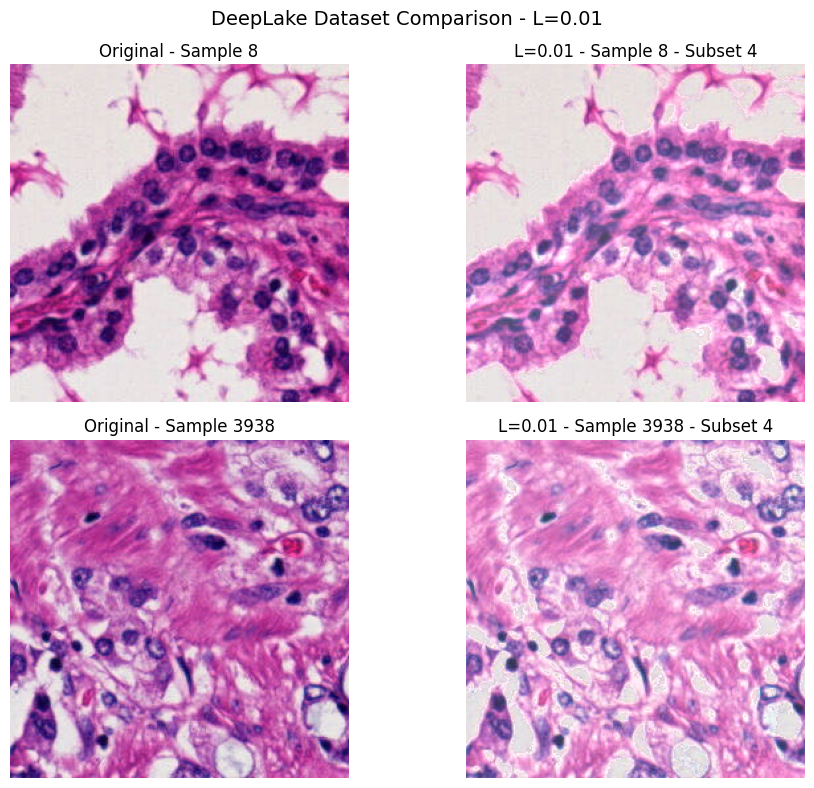

In [7]:
# checking if everything is alright

# Configuration
input_root = "/home/leolr-int/nfs/data/data/patched/dim_256/Train"  # Root directory containing all subsets
output_root = f"/home/leolr-int/nfs/transformed_data/{dataset_name}_deeplake/patched/dim_256/Train"
    
L_val = 0.01
subset_id = 4
num_examples = 2

# Dataset paths
original_ds_path = f"{input_root}/Subset3_Train_{subset_id}_KFBio"
transformed_ds_path = f"{output_root}/Subset3_Train_{subset_id}_FDA_L={L_val}"
#transformed_ds_path = f"{output_root}/Subset3_Train_{subset_id}_{dataset_name}"

# Open both datasets
original_ds = deeplake.open_read_only(original_ds_path)
transformed_ds = deeplake.open_read_only(transformed_ds_path)

print(f"Original dataset size: {len(original_ds)} samples")
print(f"Transformed dataset size: {len(transformed_ds)} samples")

# Get available indices
max_samples = min(len(original_ds), len(transformed_ds))
sample_indices = random.sample(range(max_samples), min(num_examples, max_samples))

# Create subplots
fig, axes = plt.subplots(num_examples, 2, figsize=(10, 4 * num_examples))
if num_examples == 1:
   axes = axes.reshape(1, -1)

for i, idx in enumerate(sample_indices):
   # Get samples from both datasets
   original_sample = original_ds[idx]
   transformed_sample = transformed_ds[idx]
   
   # Extract patches
   original_patch = original_sample["patch"]
   transformed_patch = transformed_sample["patch"]
   
   # Ensure patches are in (H, W, C) format for display
   if original_patch.shape[0] == 3:  # (C, H, W)
       original_patch = original_patch.transpose((1, 2, 0))
   if transformed_patch.shape[0] == 3:  # (C, H, W)
       transformed_patch = transformed_patch.transpose((1, 2, 0))
   
   # Normalize to [0, 1] for display
   original_patch = np.clip(original_patch / 255.0, 0, 1)
   transformed_patch = np.clip(transformed_patch / 255.0, 0, 1)
   
   # Display original
   axes[i, 0].imshow(original_patch)
   axes[i, 0].set_title(f"Original - Sample {idx}")
   axes[i, 0].axis('off')
   
   # Display transformed
   axes[i, 1].imshow(transformed_patch)
   axes[i, 1].set_title(f"L={L_val} - Sample {idx} - Subset {subset_id}")
   axes[i, 1].axis('off')
   
   # Print sample info
   print(f"Sample {idx}: Label={original_sample['label']}")

plt.suptitle(f"DeepLake Dataset Comparison - L={L_val}", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Embeddings generation (GigaPath)

In [8]:
def main():
    log_device()
    env_path = os.path.join(ROOT_DIR, ".env")
    load_dotenv(env_path)

    arg_path = os.path.join(CONFIG_DIR, "embed.yaml")
    args = get_args(arg_path)

    id_path = os.path.join(METADATA_DIR, "id_table.json")
    id_table = load_json(id_path)

    # path initialization for patched datasets
    train_dir = os.path.join(PATCH_DIR, f"dim_{args['patch_dim']}", "Train")
    test_dir = os.path.join(PATCH_DIR, f"dim_{args['patch_dim']}", "Test")

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    train_ds_paths = [os.path.join(train_dir, d) for d in os.listdir(train_dir)]
    test_ds_paths = [os.path.join(test_dir, d) for d in os.listdir(test_dir)]

    dest_dir = os.path.join(EMBEDDING_DIR, f"{args['precision']}_precision", f"dim_{args['patch_dim']}")

    split_table = {
        "Train": train_ds_paths,
        "Test": test_ds_paths
    }

    speed_table = {
        "slide_id": [],
        "num_patches": [],
        "start_time": [],
        "end_time": [],
        "elapsed_time": []
    }


    # clean memory
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    
    # encoder initialization
    encoder_dir = os.path.join(BASE_MODEL_DIR, "pre_trained_weights")
    model = Network(args["encoder"], encoder_dir)
    network_handler = NetworkHandler(model, precision=args["precision"])
    embedding_dim = model.fc.head.in_features

    for split in split_table.keys():
        # logging
        split_log = f"Extracting embeddings for {split}...".center(BORDER_WIDTH)
        border = "-" * BORDER_WIDTH
        print(f"\n{border}\n  {split_log}  \n{border}\n")

        split_paths = split_table[split]
        save_dir = os.path.join(dest_dir, split, args["encoder"])
        os.makedirs(save_dir, exist_ok=True)

        # dataset initialization for embeddings to be appended
        embed_ds = deeplake.create(save_dir)
        embed_ds.add_column("embedding", dtype=deeplake.types.Embedding(embedding_dim))
        embed_ds.add_column("label", dtype=deeplake.types.Int32)

        # metadata cols
        embed_ds.add_column("area", dtype=deeplake.types.Int32)
        embed_ds.add_column("x", dtype=deeplake.types.Int32)
        embed_ds.add_column("y", dtype=deeplake.types.Int32)
        embed_ds.add_column("w", dtype=deeplake.types.Int32)
        embed_ds.add_column("h", dtype=deeplake.types.Int32)
        embed_ds.add_column("img_idx", dtype=deeplake.types.Int32)

        # embedding extraction
        num_samples = len(split_paths)
        for i, ds_path in enumerate(split_paths):
            img_id = Path(ds_path).name

            # this is used for the new dataset i generated
            img_id = img_id.split("_FDA_L=")[0] + '_KFBio'

            if scanner not in img_id:
                continue  # Skip files that don't contain the scanner

            img_idx = id_table[img_id]

            print(f"{img_id} | [{i+1}/{num_samples}]")
            print(ds_path)
            
            try:
                patch_ds = deeplake.open_read_only(ds_path).pytorch(transform=img_transform_fn)
                patch_loader = DataLoader(
                    patch_ds,
                    batch_size=args["batch_size"],
                    shuffle=False
                )

                start_time = datetime.now()
                network_handler.extract_embeddings(patch_loader, embed_ds, img_idx=img_idx)
                end_time = datetime.now()

                elapsed_time = end_time - start_time

                speed_table["slide_id"].append(img_id)
                speed_table["num_patches"].append(len(patch_ds))
                speed_table["start_time"].append(start_time)
                speed_table["end_time"].append(end_time)
                speed_table["elapsed_time"].append(elapsed_time)

            except Exception as e:
                print(f"Error: {e}")

            print(f"\n{border}\n")

    save_table(
        speed_table, 
        save_dir=os.path.join(PROFILING_DIR, "embedding", f"{args['precision']}_precision"), 
        filename=f"{args['encoder']}_speed_table"
    )


if __name__ == "__main__":
    main()


                               Devices                                
----------------------------------------------------------------------

                  GPU 0: NVIDIA GeForce RTX 3080 Ti                   
                       Memory Used : 545.94 MB                        
                      Memory Total: 12288.00 MB                       

----------------------------------------------------------------------
                     PyTorch CUDA Available: True                     


----------------------------------------------------------------------
                    Extracting embeddings for Train...                    
----------------------------------------------------------------------

Subset3_Train_9_KFBio | [1/26]
/home/leolr-int/nfs/transformed_data/FDA_CD_deeplake/patched/dim_256/Train/Subset3_Train_9_FDA_L=0.01


Extracting embeddings: 100%|██████████████████████████████████████████████████████████████████████████| 21/21 [02:04<00:00,  5.92s/it]



----------------------------------------------------------------------

Subset3_Train_15_KFBio | [2/26]
/home/leolr-int/nfs/transformed_data/FDA_CD_deeplake/patched/dim_256/Train/Subset3_Train_15_FDA_L=0.01


Extracting embeddings: 100%|██████████████████████████████████████████████████████████████████████████| 14/14 [01:26<00:00,  6.19s/it]



----------------------------------------------------------------------

Subset3_Train_24_KFBio | [3/26]
/home/leolr-int/nfs/transformed_data/FDA_CD_deeplake/patched/dim_256/Train/Subset3_Train_24_FDA_L=0.01


...


----------------------------------------------------------------------

Subset3_Train_3_KFBio | [25/26]
/home/leolr-int/nfs/transformed_data/FDA_CD_deeplake/patched/dim_256/Train/Subset3_Train_3_FDA_L=0.01


Extracting embeddings: 100%|██████████████████████████████████████████████████████████████████████████| 26/26 [02:08<00:00,  4.95s/it]



----------------------------------------------------------------------

Subset3_Train_25_KFBio | [26/26]
/home/leolr-int/nfs/transformed_data/FDA_CD_deeplake/patched/dim_256/Train/Subset3_Train_25_FDA_L=0.01


Extracting embeddings: 100%|██████████████████████████████████████████████████████████████████████████| 42/42 [04:16<00:00,  6.11s/it]



----------------------------------------------------------------------


----------------------------------------------------------------------
                    Extracting embeddings for Test...                     
----------------------------------------------------------------------



## 3. Linear probing

In [9]:
#download weight of needed
download = False
if download:

    from huggingface_hub import login
    login(token="-")
    
    encoder_dir = os.path.join(BASE_MODEL_DIR, "pre_trained_weights")
    encoder = Network("gigapath", encoder_dir).encoder


def linear_probing(weights_path, dataset):
    
    state_dict = torch.load(weights_path)

    weight = state_dict['head.weight'] # shape: [5, 1536]
    bias = state_dict.get('head.bias', None)  # shape: [5]
   
    EMBEDDING_DIR = f"/home/leolr-int/nfs/transformed_data/new_embeddings/{dataset}"  # or KFBio, etc.
    embedding_path = os.path.join(EMBEDDING_DIR, "mixed_precision", "dim_256", "Train", "gigapath")

    ds = deeplake.open_read_only(embedding_path)
    ds_torch = ds.pytorch(transform=embedding_transform_fn)
    ds_loader = DataLoader(ds_torch, batch_size=64, shuffle=False)  # larger batch_size for efficiency
    weight = weight.cpu()
    bias = bias.cpu()

    all_preds = []
    all_labels = []

    for batch in tqdm(ds_loader, desc="Linear probing"):
        embedding, label, _ = batch  
        
        # Linear probing: logits = embedding @ W^T + b
        logits = embedding @ weight.T + bias

        preds = torch.argmax(F.softmax(logits, dim=1), dim=1)

        all_preds.append(preds)
        all_labels.append(label)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Convert to CPU numpy arrays for sklearn
    y_true = all_labels.cpu().numpy()
    y_pred = all_preds.cpu().numpy()

    return [y_true, y_pred]

def metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)


    print(f" - Accuracy : {acc:.4f}")
    print(f" - Precision: {precision:.4f}")
    print(f" - Recall   : {recall:.4f}")
    print(f" - F1-score : {f1:.4f}")

    labels_name=['Stroma', 'Normal', 'G3', 'G4', 'G5']

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred, normalize='true')    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, cmap='PuRd',xticklabels=labels_name, yticklabels=labels_name)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

In [10]:
# test on my weights (trained only using Subset3_Train_{i}_Akoya)
model_dir = "/home/leolr-int/nfs/transformed_data/weights"
my_weights = os.path.join(model_dir, "final_model.pth")

KFBio_pred=linear_probing(my_weights, 'KFBio')
FDA_CD_pred=linear_probing(my_weights, dataset_name)

Linear probing: 100%|█████████████████████████████████████████████████████████████████████████████| 3086/3086 [01:59<00:00, 25.93it/s]


 - Accuracy : 0.8394
 - Precision: 0.8406
 - Recall   : 0.8394
 - F1-score : 0.8385


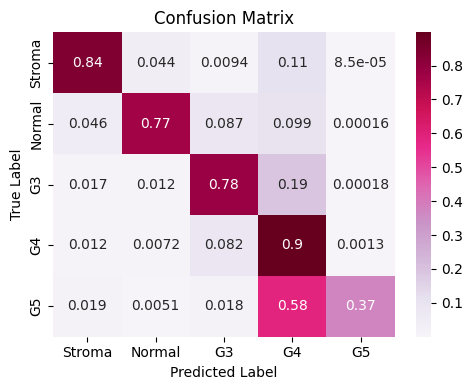

 - Accuracy : 0.8430
 - Precision: 0.8490
 - Recall   : 0.8430
 - F1-score : 0.8427


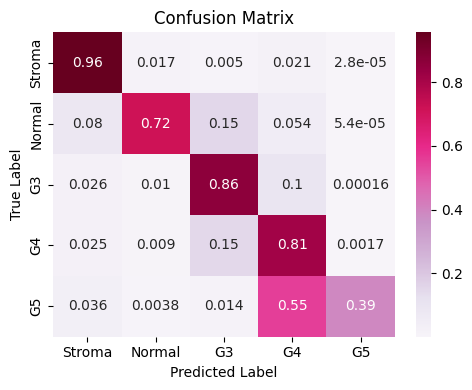

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 299, in dispatch_control
    await self.process_control(msg)
  File "/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 305, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/jupyter_client/session.py", line 994, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/le

In [11]:
metrics(KFBio_pred[0], KFBio_pred[1])
metrics(FDA_CD_pred[0], FDA_CD_pred[1])